In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('Laptop_data_50B.csv')
df

,BrandName,ModelName,Price,Processor,RAM,Storage,RatingsCount,ReviewsCount
0,Lenovo,Lenovo 100e Chromebook Gen 4,9999,MediaTek Kompanio 520 Processor,4 GB,512 GB SSD,572,51
1,Acer,Acer Aspire 3,17990,Intel Celeron Dual Core Processor,8 GB,512 GB SSD,1938,200
2,Acer,Acer Aspire 3 Backlit,38990,AMD Ryzen 7 Octa Core Processor,16 GB,512 GB SSD,801,57
3,Acer,Acer Aspire 3,22990,Intel Celeron Dual Core Processor,8 GB,512 GB SSD,2774,219
4,Acer,Acer Aspire 3,27990,Intel Core i3 Processor (13th Gen),8 GB,256 GB SSD,2090,161
...,...,...,...,...,...,...,...,...
1771,Acer,Acer Aspire 3,21990,Intel Celeron Dual Core Processor,8 GB,512 GB SSD,2774,219
1772,ASUS,ASUS Expertbook P1,66990,Intel Core i7 Processor (13th Gen),32 GB,512 GB SSD,221,25
1773,ASUS,ASUS Expertbook P1,34490,Intel Core i3 Processor (13th Gen),8 GB,512 GB SSD,889,94
1774,ASUS,ASUS Vivobook S14 (2025) with Office 2024 + M3...,58990,Intel Core i5 Processor (13th Gen),8 GB,512 GB SSD,140,11


In [4]:
# Groupby → Average laptop price per brand
avg_price_per_brand = df.groupby("BrandName")["Price"].mean().reset_index()

print(avg_price_per_brand)

  BrandName         Price
0      ASUS  49209.412724
1      Acer  28921.210191
2     CHUWI  17990.000000
3      DELL  72990.000000
4        HP  54240.000000
5    Lenovo  12332.333333
6  MOTOROLA  54990.000000
7       MSI  46900.000000
8   Samsung  36990.000000


In [5]:
# Pivot table: Brand × RAM → Average Price
pivot_price_brand_ram = pd.pivot_table(
    df,
    values="Price",
    index="BrandName",
    columns="RAM",
    aggfunc="mean"
).reset_index()

print(pivot_price_brand_ram)

RAM BrandName         16 GB    32 GB     4 GB          8 GB
0        ASUS  47668.423237  63277.5  13990.0  47080.277778
1        Acer  38543.333333      NaN      NaN  22969.381443
2       CHUWI           NaN      NaN      NaN  17990.000000
3        DELL  72990.000000      NaN      NaN           NaN
4          HP  56353.636364      NaN      NaN  30990.000000
5      Lenovo           NaN      NaN  10499.0  15999.000000
6    MOTOROLA  54990.000000      NaN      NaN           NaN
7         MSI  46900.000000      NaN      NaN           NaN
8     Samsung           NaN      NaN      NaN  36990.000000


In [6]:
# Crosstab: Count of laptops for each Brand-RAM combination
crosstab_brand_ram = pd.crosstab(df["BrandName"], df["RAM"])

print(crosstab_brand_ram)

RAM        16 GB  32 GB  4 GB  8 GB
BrandName                          
ASUS         241     80     4   288
Acer         300      0     0   485
CHUWI          0      0     0    10
DELL          20      0     0     0
HP            44      0     0     4
Lenovo         0      0   148    74
MOTOROLA      70      0     0     0
MSI            4      0     0     0
Samsung        0      0     0     4


In [7]:
# Groupby: Average Price & Ratings per Brand
groupby_price_ratings = df.groupby("BrandName")[["Price", "RatingsCount"]].mean().reset_index()

print(groupby_price_ratings)

  BrandName         Price  RatingsCount
0      ASUS  49209.412724    574.004894
1      Acer  28921.210191   2031.545223
2     CHUWI  17990.000000   1697.000000
3      DELL  72990.000000     19.000000
4        HP  54240.000000    454.083333
5    Lenovo  12332.333333    364.000000
6  MOTOROLA  54990.000000    349.000000
7       MSI  46900.000000     14.000000
8   Samsung  36990.000000   5315.000000


In [8]:
# Pivot table: Brand × RAM → Average Price
pivot_price_brand_ram = pd.pivot_table(
    df,
    values="Price",
    index="BrandName",
    columns="RAM",
    aggfunc="mean"
).reset_index()

print(pivot_price_brand_ram)

RAM BrandName         16 GB    32 GB     4 GB          8 GB
0        ASUS  47668.423237  63277.5  13990.0  47080.277778
1        Acer  38543.333333      NaN      NaN  22969.381443
2       CHUWI           NaN      NaN      NaN  17990.000000
3        DELL  72990.000000      NaN      NaN           NaN
4          HP  56353.636364      NaN      NaN  30990.000000
5      Lenovo           NaN      NaN  10499.0  15999.000000
6    MOTOROLA  54990.000000      NaN      NaN           NaN
7         MSI  46900.000000      NaN      NaN           NaN
8     Samsung           NaN      NaN      NaN  36990.000000


In [9]:
# Pivot table: Processor × Brand → Average Ratings
pivot_ratings_processor_brand = pd.pivot_table(
    df,
    values="RatingsCount",
    index="Processor",
    columns="BrandName",
    aggfunc="mean"
).reset_index()

print(pivot_ratings_processor_brand)

BrandName                                          Processor         ASUS  \
0                            AMD Ryzen 3 Quad Core Processor          NaN   
1                            AMD Ryzen 5 Hexa Core Processor          NaN   
2                            AMD Ryzen 7 Octa Core Processor          NaN   
3                          Intel Celeron Dual Core Processor  2760.000000   
4                          Intel Core 5 (Series 2) Processor          NaN   
5                               Intel Core Ultra 5 Processor          NaN   
6                         Intel Core i3 Processor (12th Gen)          NaN   
7                         Intel Core i3 Processor (13th Gen)   889.000000   
8                         Intel Core i5 Processor (12th Gen)          NaN   
9                         Intel Core i5 Processor (13th Gen)   416.335907   
10                        Intel Core i7 Processor (12th Gen)          NaN   
11                        Intel Core i7 Processor (13th Gen)   221.000000   

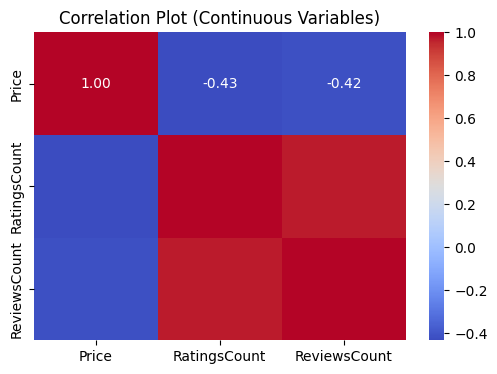

In [10]:
# Select only continuous variables
continuous_vars = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr_matrix = continuous_vars.corr()

# Plot correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Plot (Continuous Variables)")
plt.show()

In [11]:
# Crosstab: Count of laptops for each Brand-RAM combination
crosstab_brand_ram = pd.crosstab(df["BrandName"], df["RAM"])

print(crosstab_brand_ram)

RAM        16 GB  32 GB  4 GB  8 GB
BrandName                          
ASUS         241     80     4   288
Acer         300      0     0   485
CHUWI          0      0     0    10
DELL          20      0     0     0
HP            44      0     0     4
Lenovo         0      0   148    74
MOTOROLA      70      0     0     0
MSI            4      0     0     0
Samsung        0      0     0     4


In [12]:
# Crosstab: Count of laptops for each Brand-Processor combination
crosstab_brand_processor = pd.crosstab(df["BrandName"], df["Processor"])

print(crosstab_brand_processor)

Processor  AMD Ryzen 3 Quad Core Processor  AMD Ryzen 5 Hexa Core Processor  \
BrandName                                                                     
ASUS                                     0                                0   
Acer                                     0                               75   
CHUWI                                    0                                0   
DELL                                     0                                0   
HP                                       4                                0   
Lenovo                                   0                                0   
MOTOROLA                                 0                                0   
MSI                                      0                                0   
Samsung                                  0                                0   

Processor  AMD Ryzen 7 Octa Core Processor  Intel Celeron Dual Core Processor  \
BrandName                                        

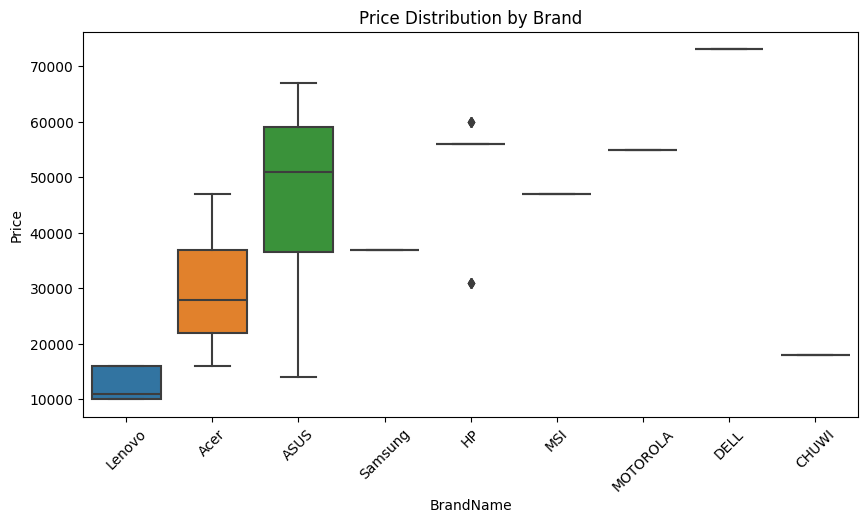

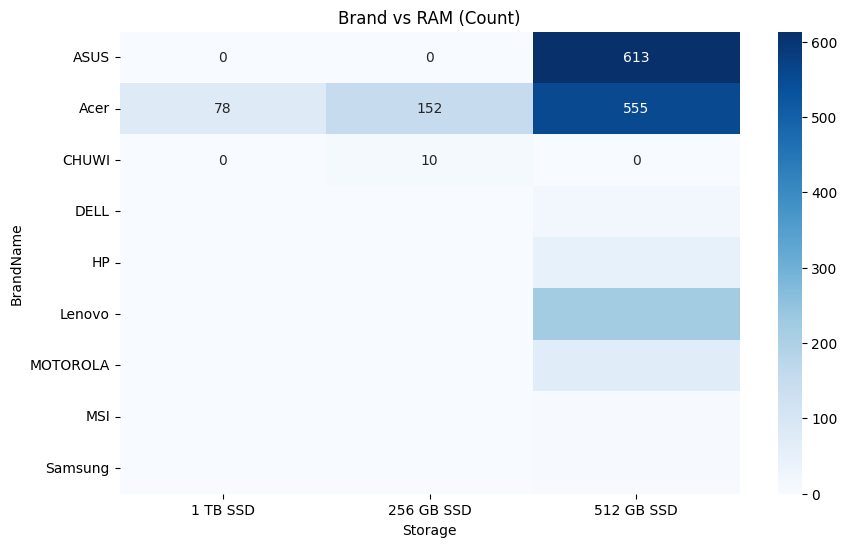

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17980\3275612301.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='BrandName', y='Price', estimator='mean', ci=None)


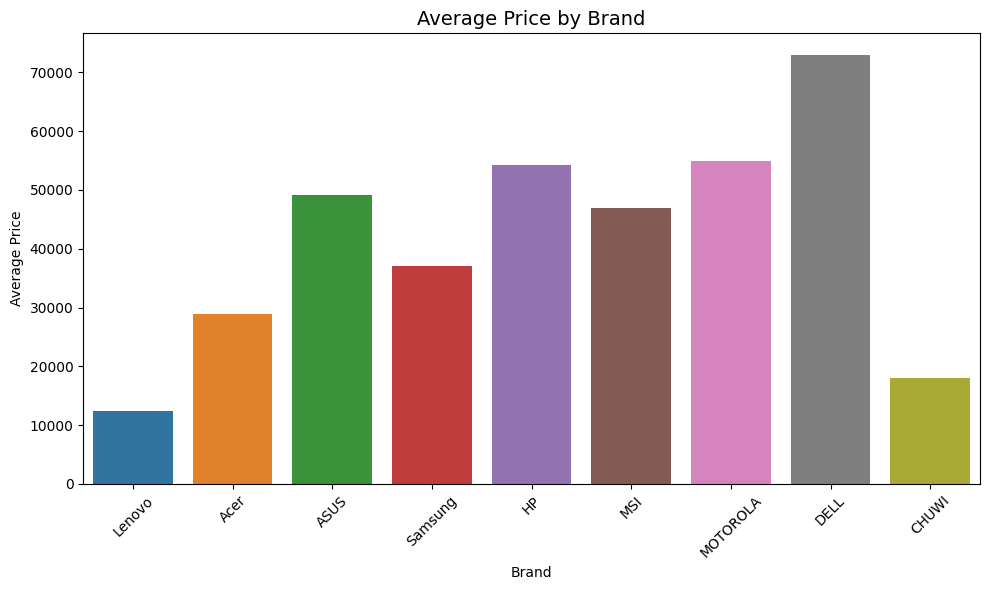

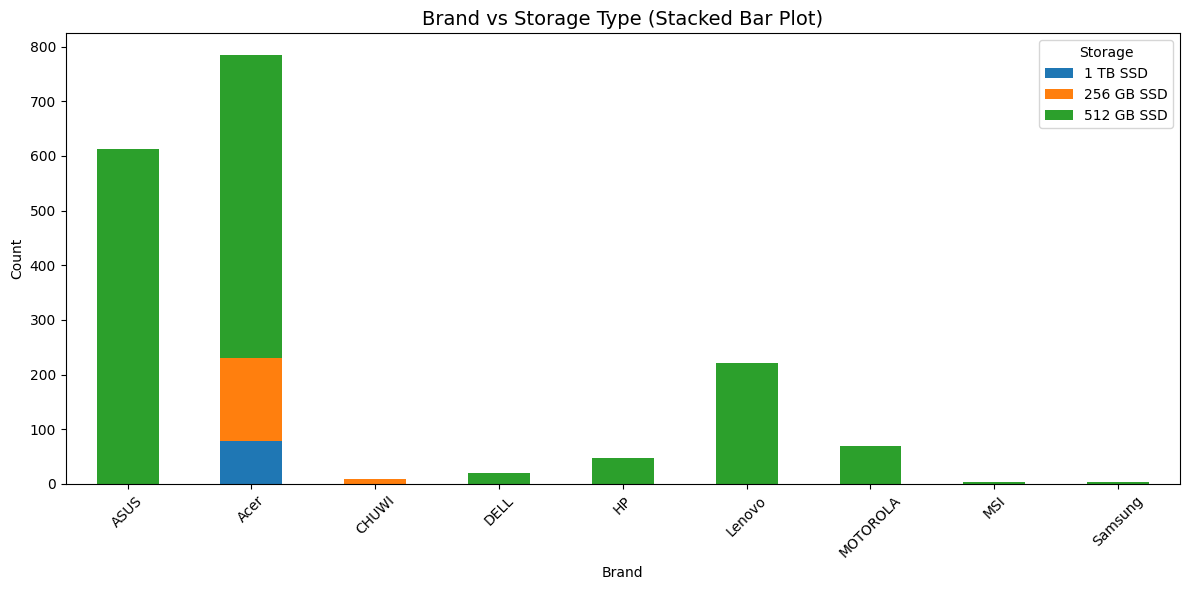

In [20]:
# -------------------------------
# Visualizations
# -------------------------------

# Boxplot: Continuous vs Categorical
plt.figure(figsize=(10, 5))
sns.boxplot(x='BrandName', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("Price Distribution by Brand")
plt.show()

# Crosstab Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_result, annot=True, fmt='d', cmap='Blues')
plt.title("Brand vs RAM (Count)")
plt.show()

# Bar chart 
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='BrandName', y='Price', estimator='mean', ci=None)
plt.xticks(rotation=45)
plt.title('Average Price by Brand', fontsize=14)
plt.ylabel('Average Price')
plt.xlabel('Brand')
plt.tight_layout()
plt.show()

#Stacked bar plot
crosstab_result = pd.crosstab(df['BrandName'], df['Storage'])

# Plot stacked bar chart
crosstab_result.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Brand vs Storage Type (Stacked Bar Plot)', fontsize=14)
plt.ylabel('Count')
plt.xlabel('Brand')
plt.xticks(rotation=45)
plt.legend(title='Storage')
plt.tight_layout()
plt.show()

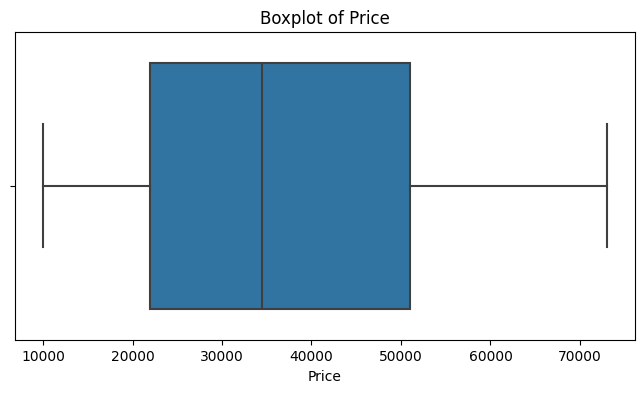

C:\Users\ASUS\Downloads\New folder\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


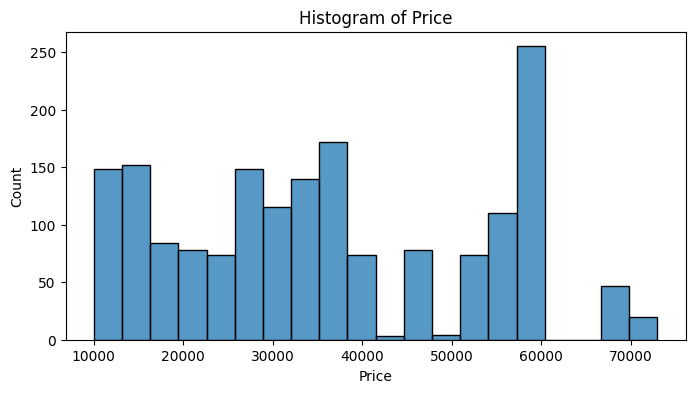

C:\Users\ASUS\Downloads\New folder\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


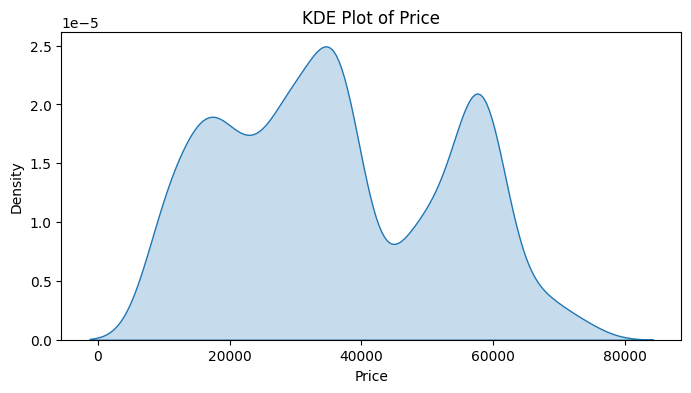

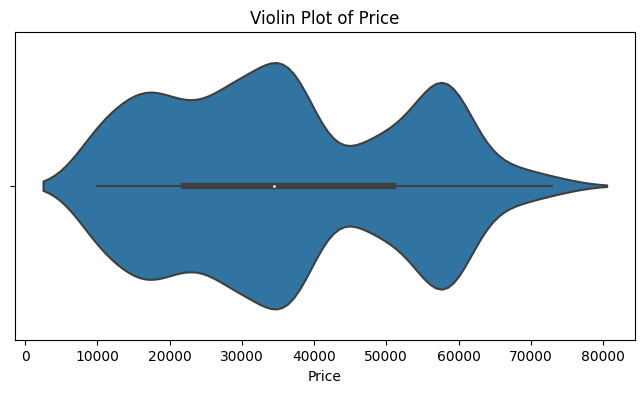

C:\Users\ASUS\Downloads\New folder\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


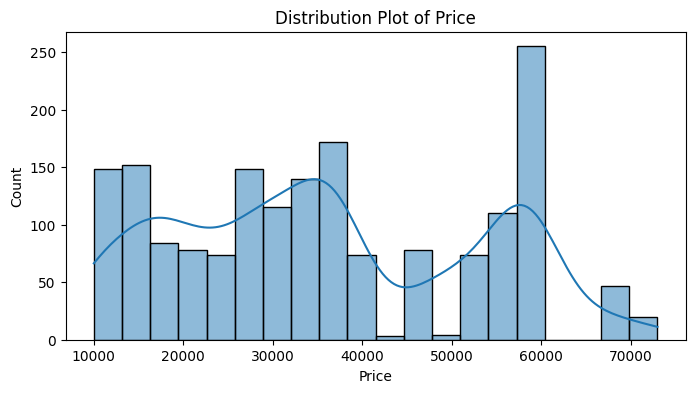

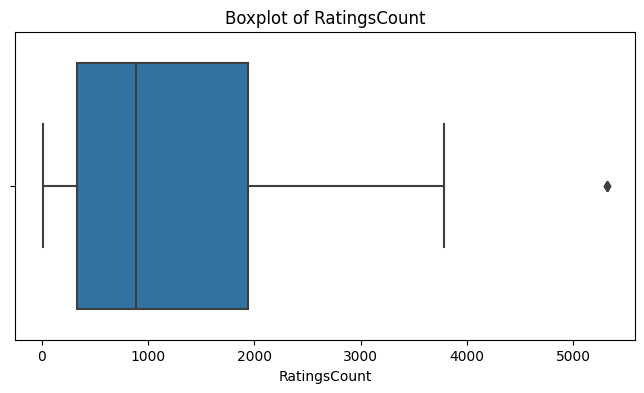

C:\Users\ASUS\Downloads\New folder\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


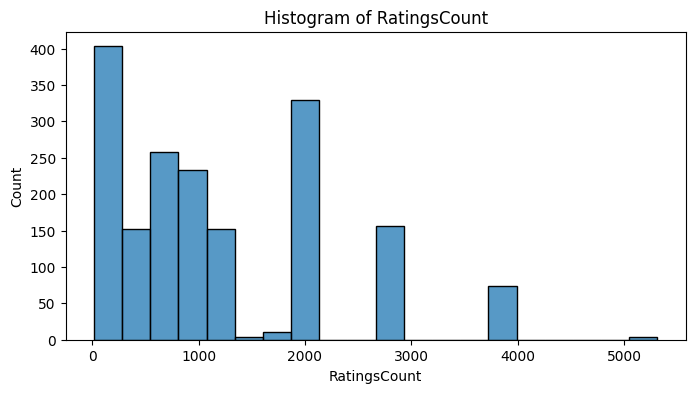

C:\Users\ASUS\Downloads\New folder\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


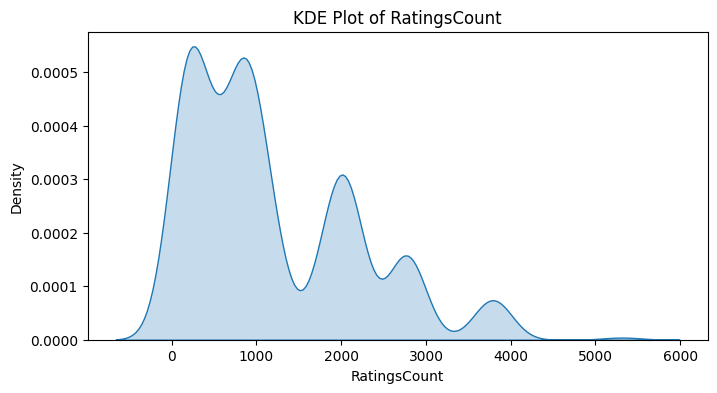

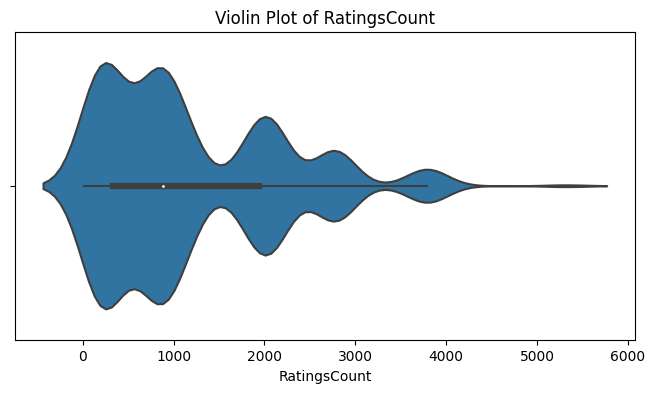

C:\Users\ASUS\Downloads\New folder\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


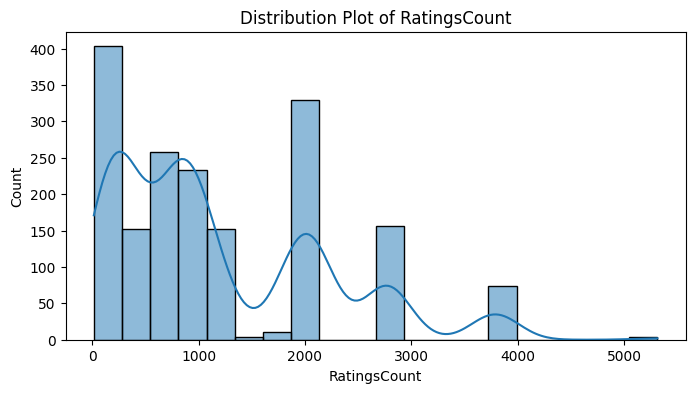

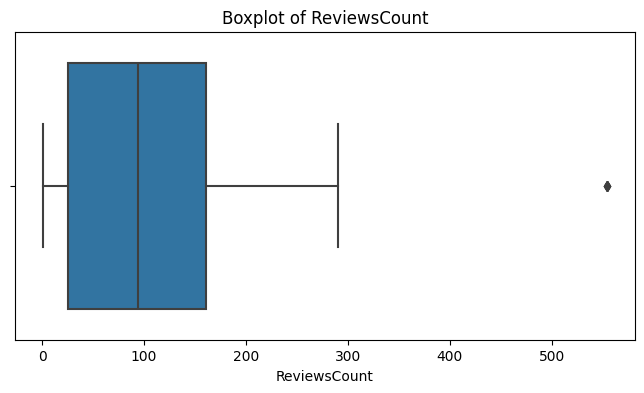

C:\Users\ASUS\Downloads\New folder\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


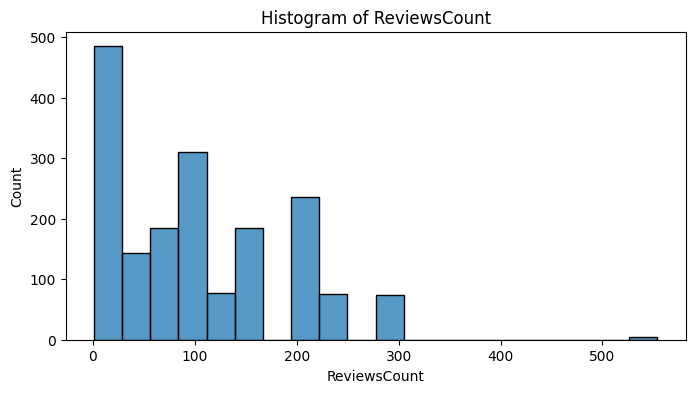

C:\Users\ASUS\Downloads\New folder\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


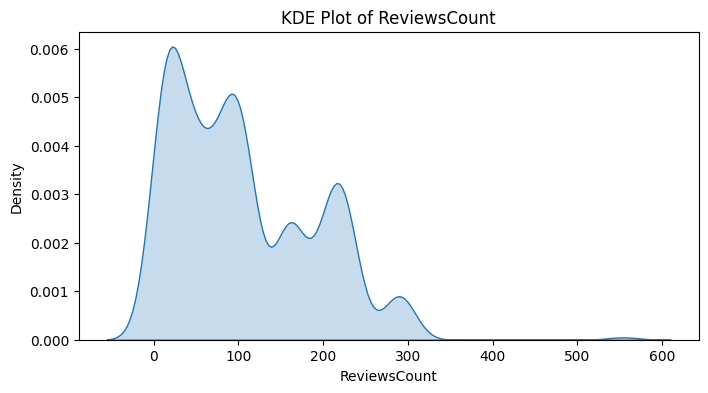

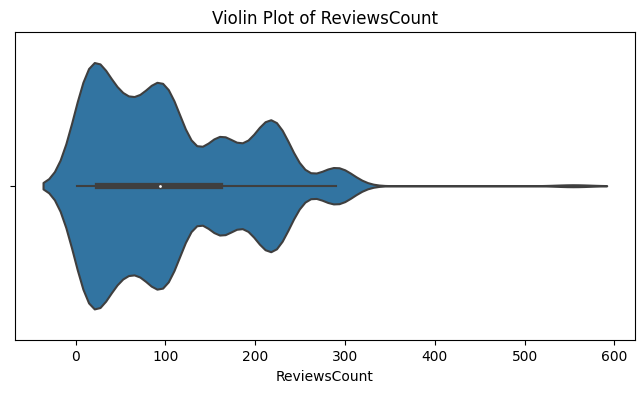

C:\Users\ASUS\Downloads\New folder\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


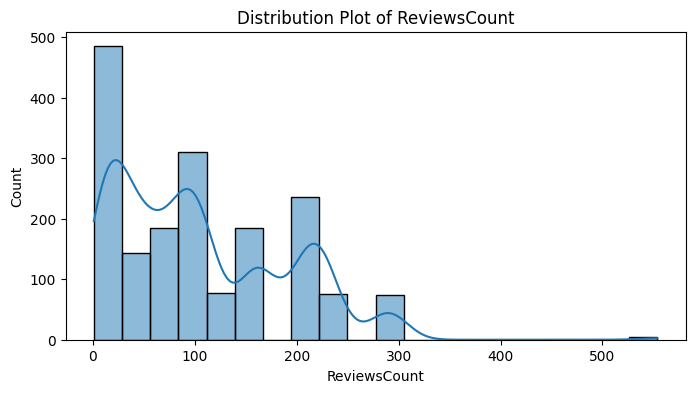

In [17]:
#Plots we can be drawn based on the data features/columns

# Separate numeric & categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns

# ---------------------------
# Numeric variable plots
# ---------------------------
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
    
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=False, bins=20)
    plt.title(f'Histogram of {col}')
    plt.show()
    
    plt.figure(figsize=(8, 4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f'KDE Plot of {col}')
    plt.show()
    
    plt.figure(figsize=(8, 4))
    sns.violinplot(x=df[col])
    plt.title(f'Violin Plot of {col}')
    plt.show()
    
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution Plot of {col}')
    plt.show()


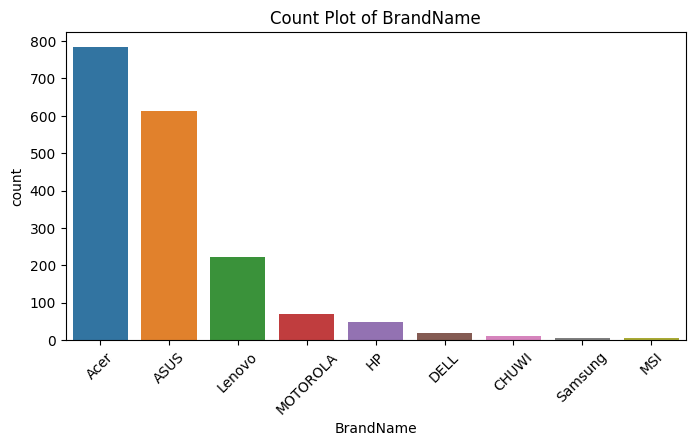

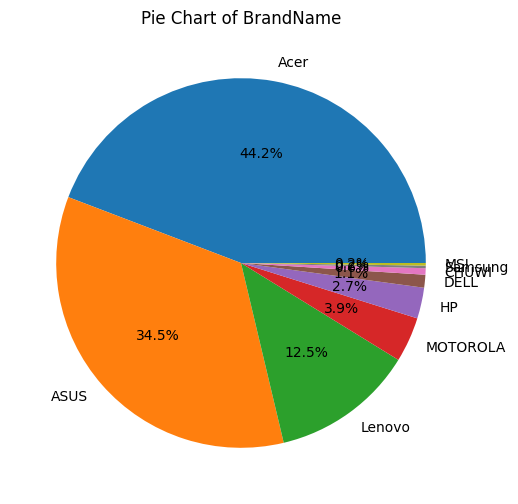

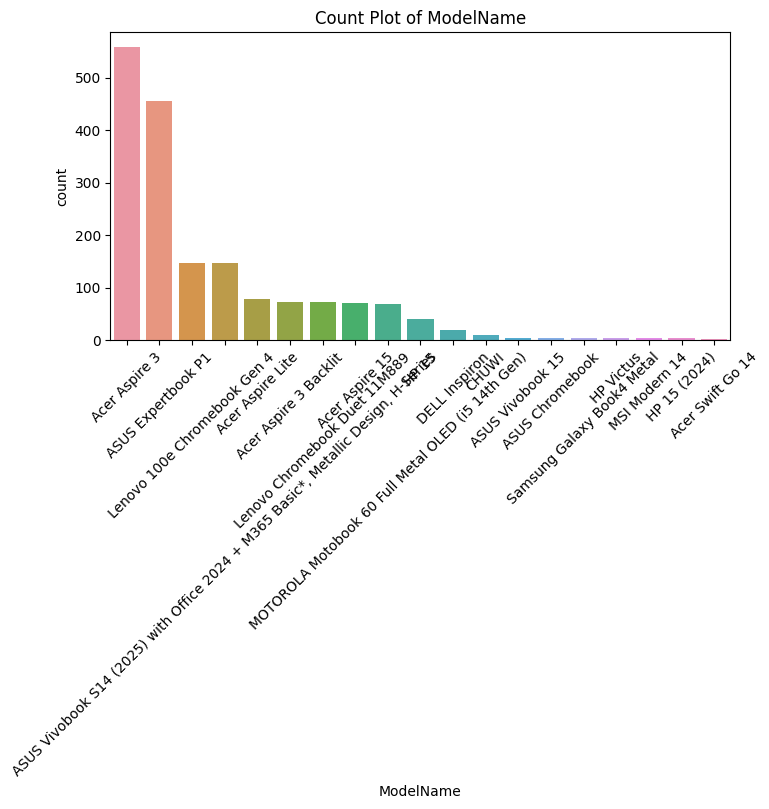

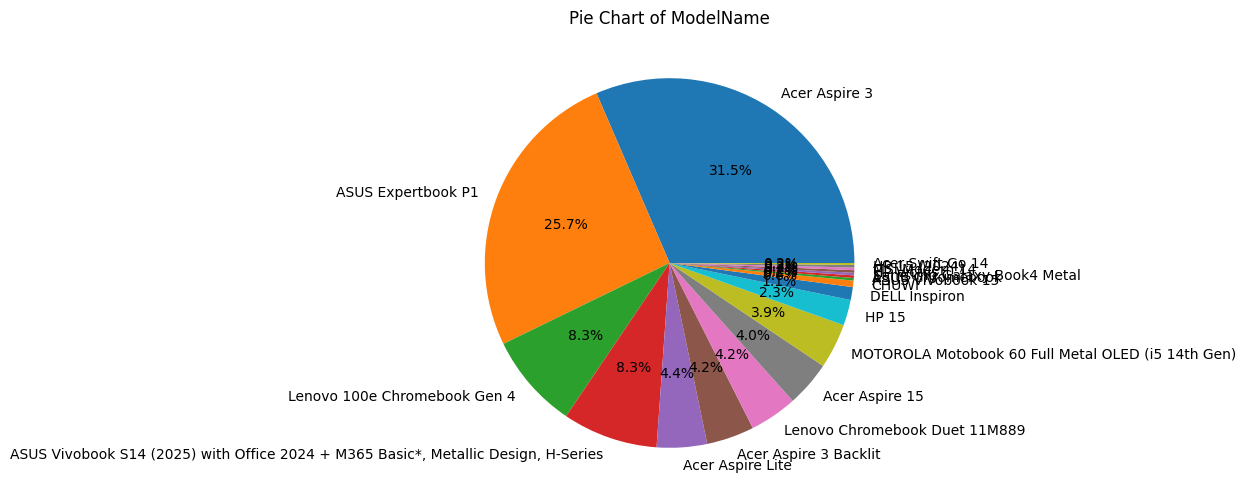

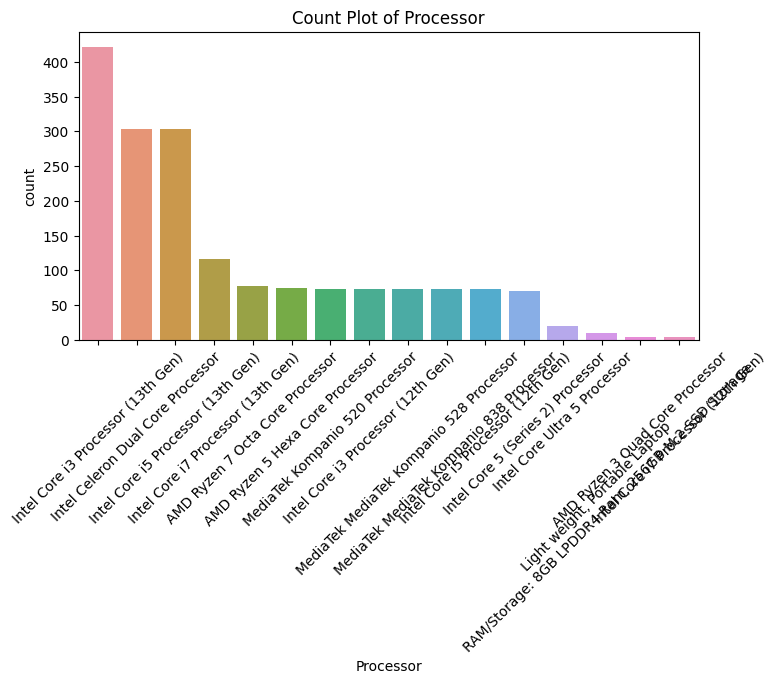

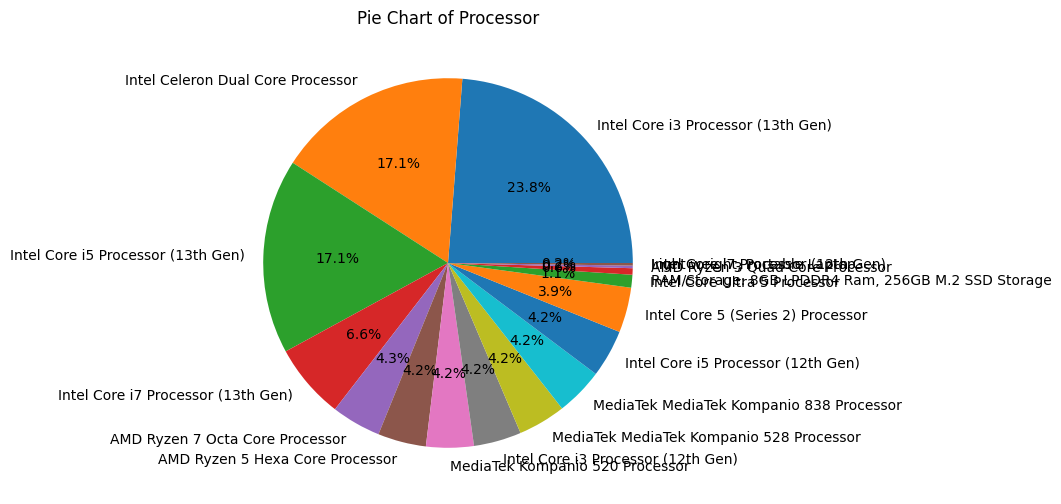

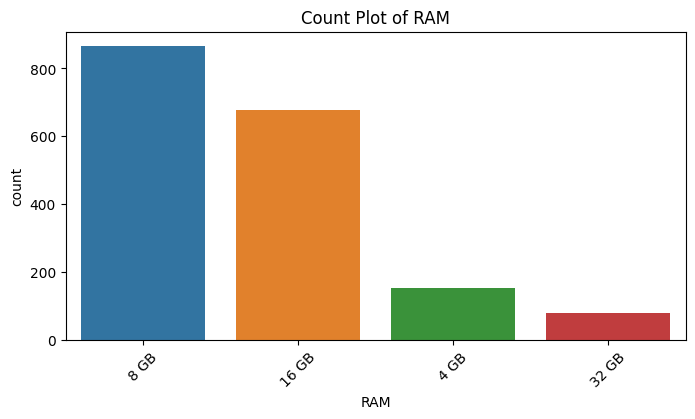

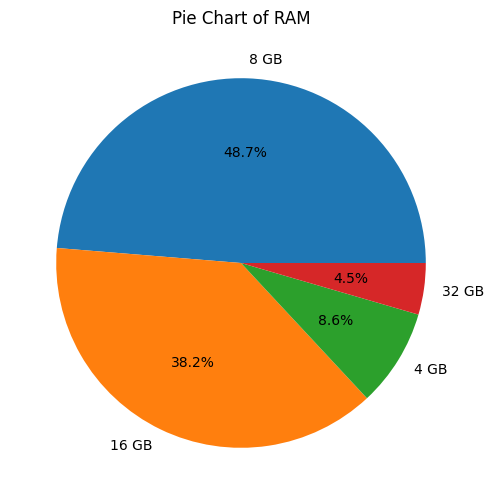

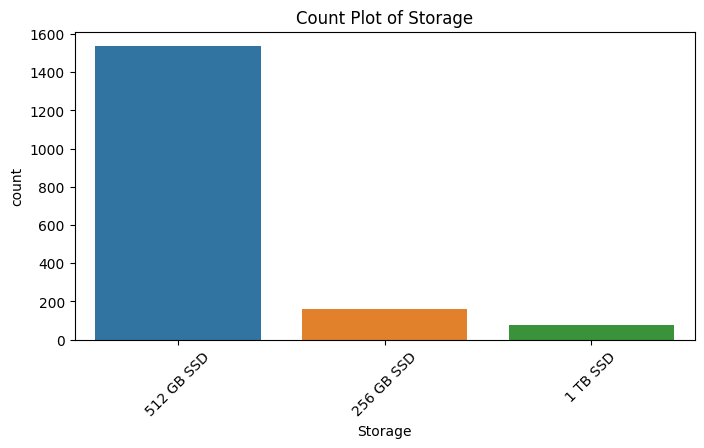

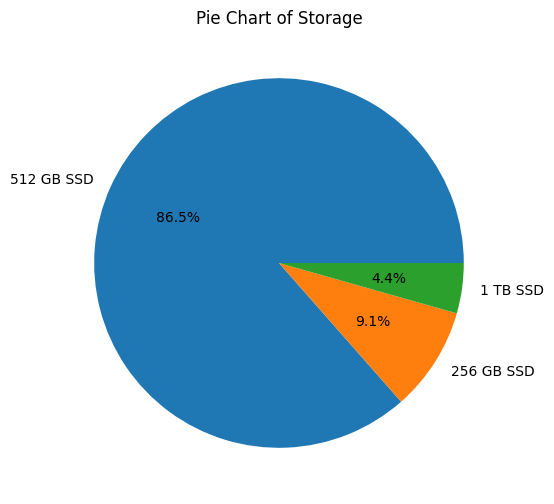

In [18]:
# ---------------------------
# Categorical variable plots
# ---------------------------
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Count Plot of {col}')
    plt.show()
    
    plt.figure(figsize=(6, 6))
    df[col].value_counts().plot.pie(autopct='%1.1f%%')
    plt.ylabel('')
    plt.title(f'Pie Chart of {col}')
    plt.show()